In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from warnings import filterwarnings
import joblib
filterwarnings('ignore')

%matplotlib inline

In [89]:
data = pd.read_csv("HR-Employee-Attrition.csv")

In [90]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [92]:
data.duplicated().sum()

np.int64(0)

In [93]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [94]:
data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

<Axes: xlabel='Attrition', ylabel='count'>

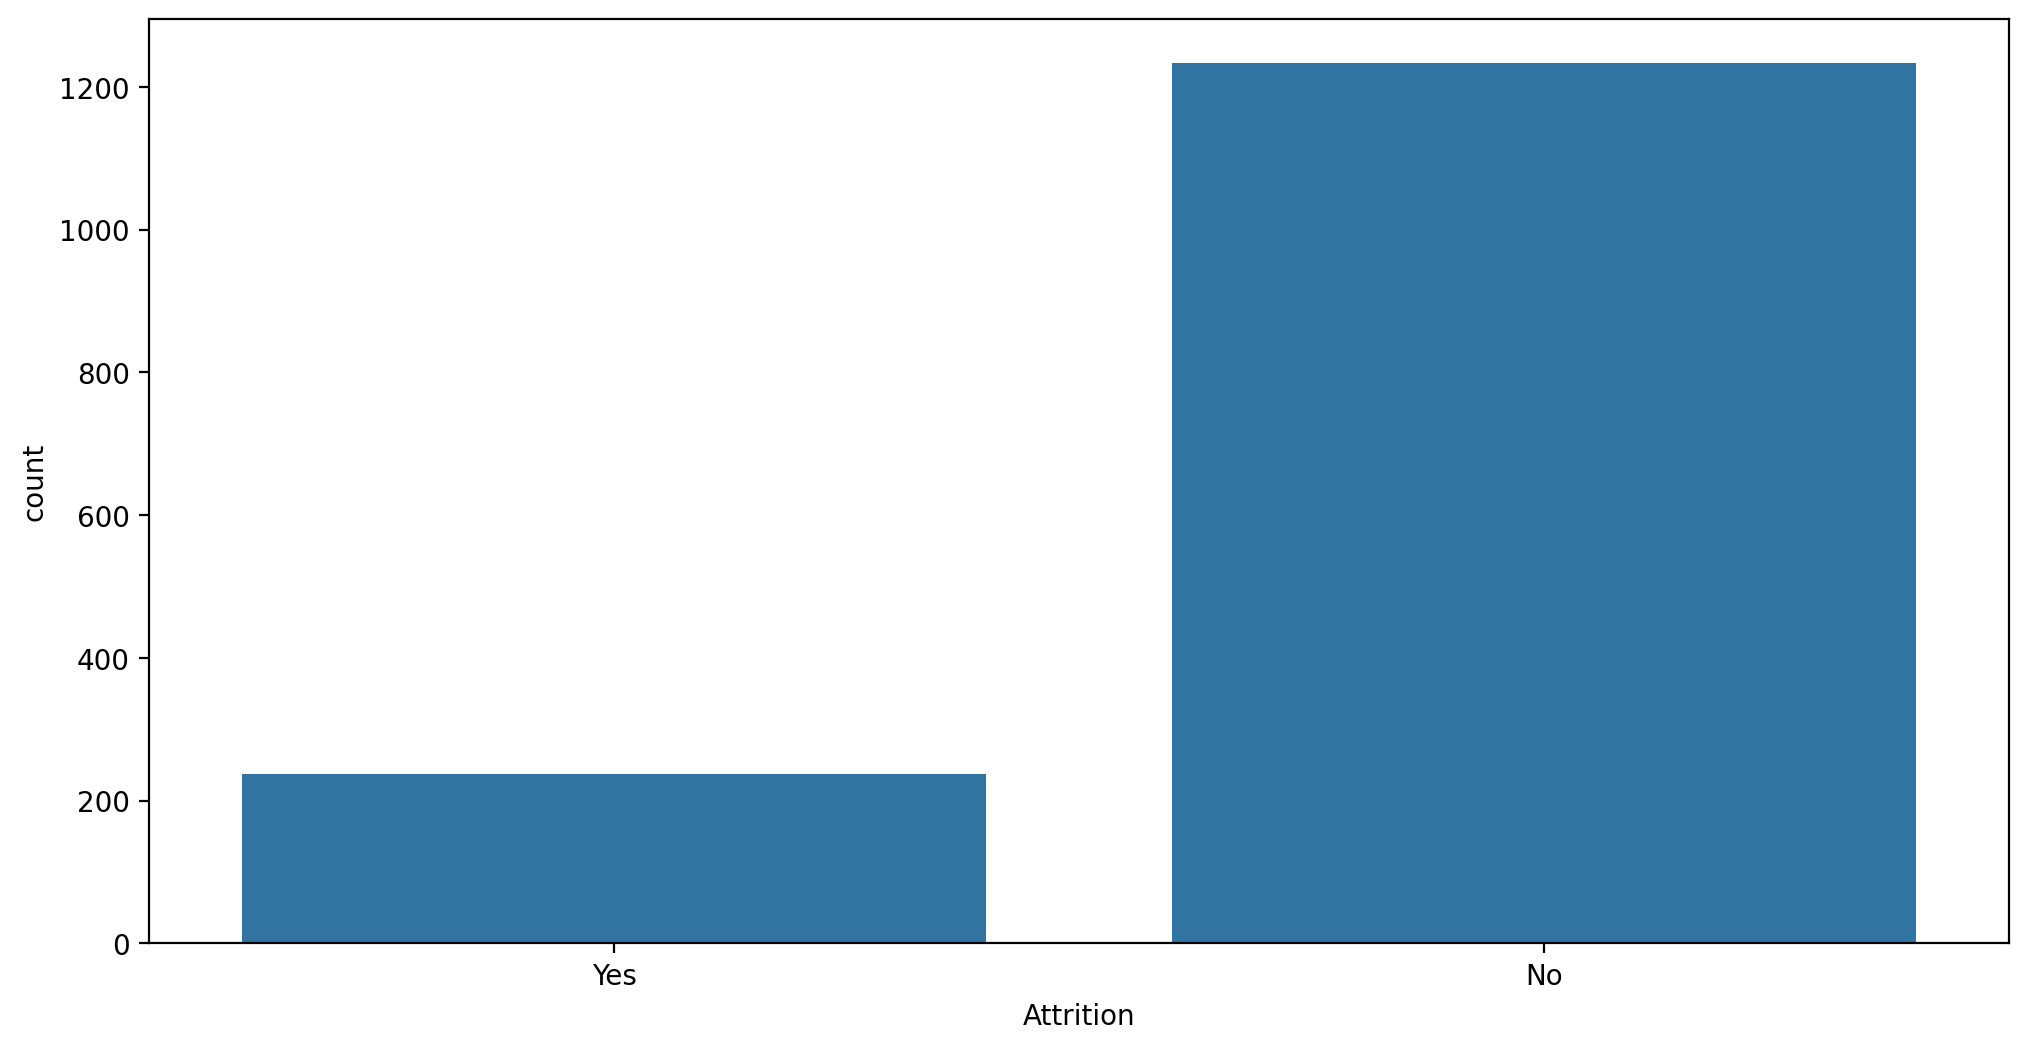

In [95]:
# Attrition distribution
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='Attrition', data=data)

<Axes: xlabel='OverTime', ylabel='count'>

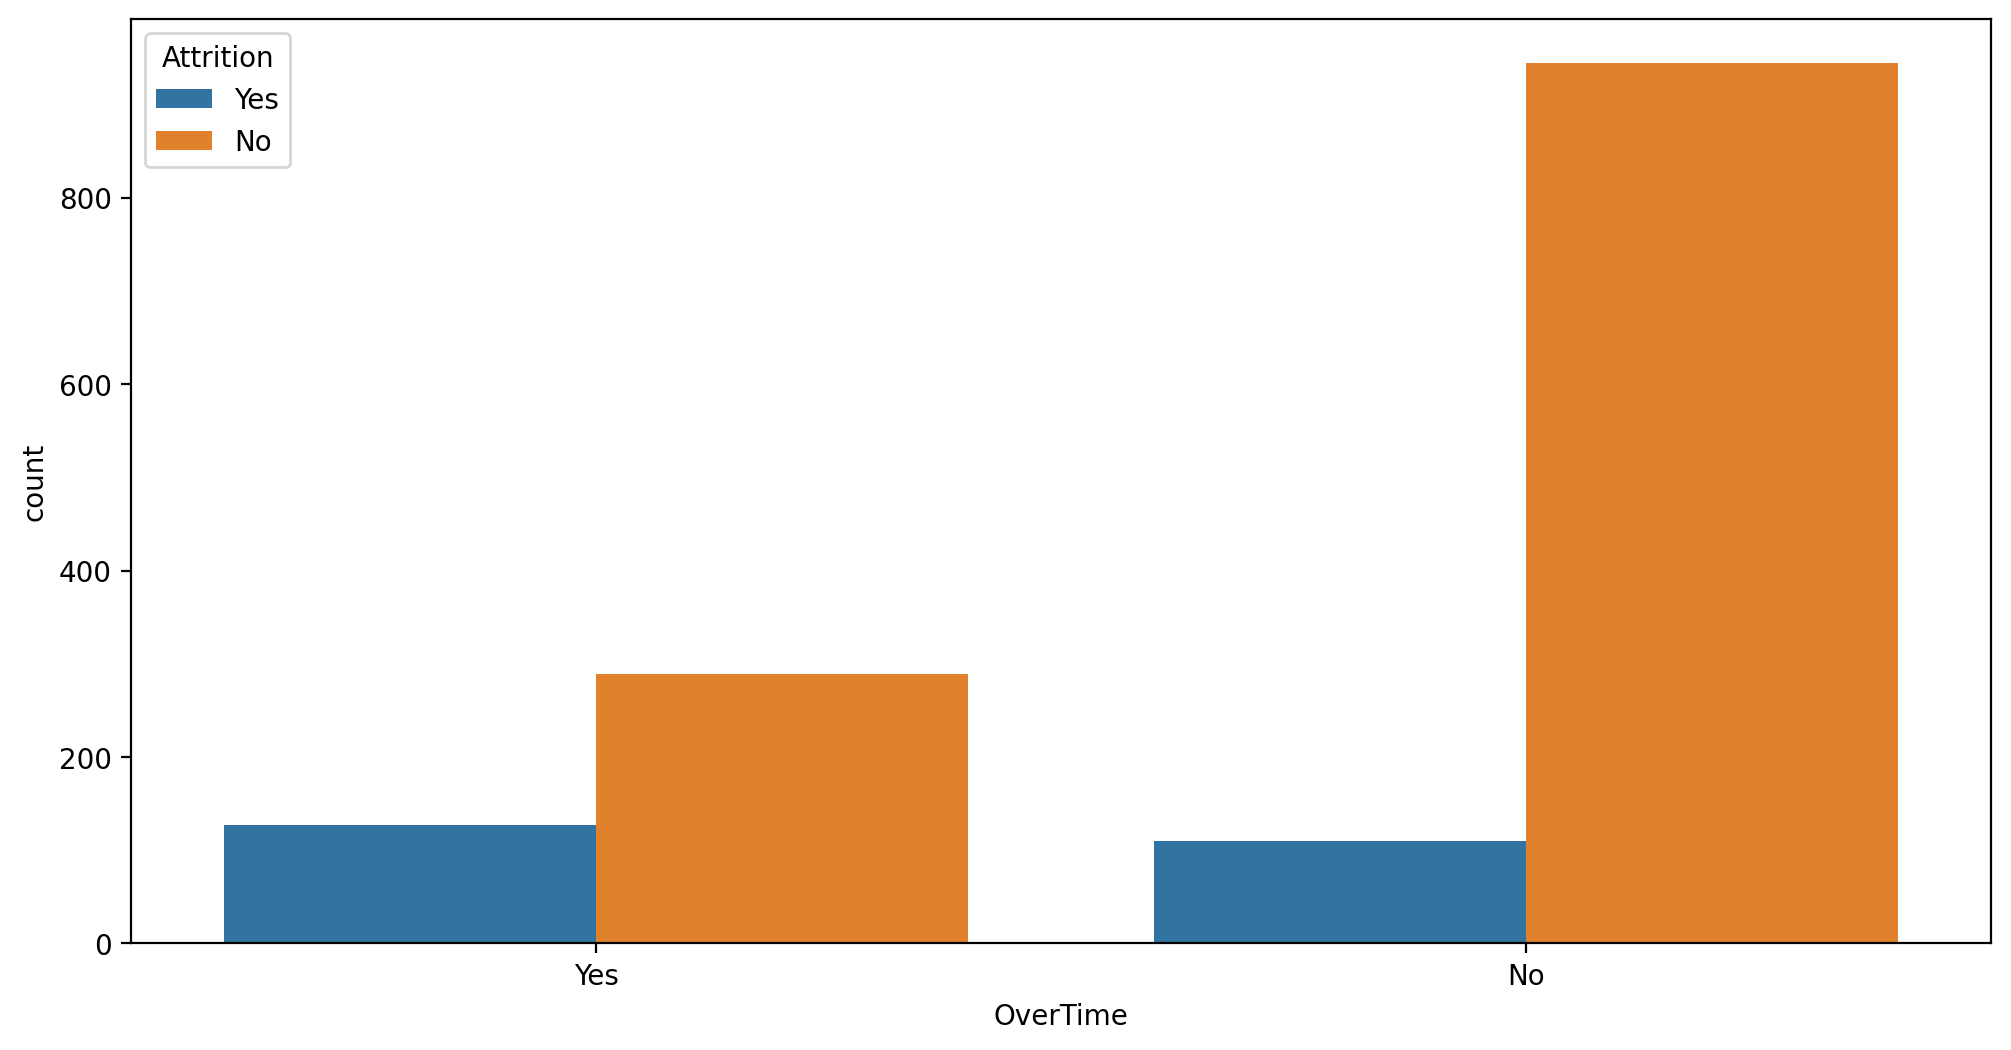

In [96]:
# Attrition vs Overtime
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='OverTime', hue='Attrition', data=data)

<Axes: xlabel='Department', ylabel='count'>

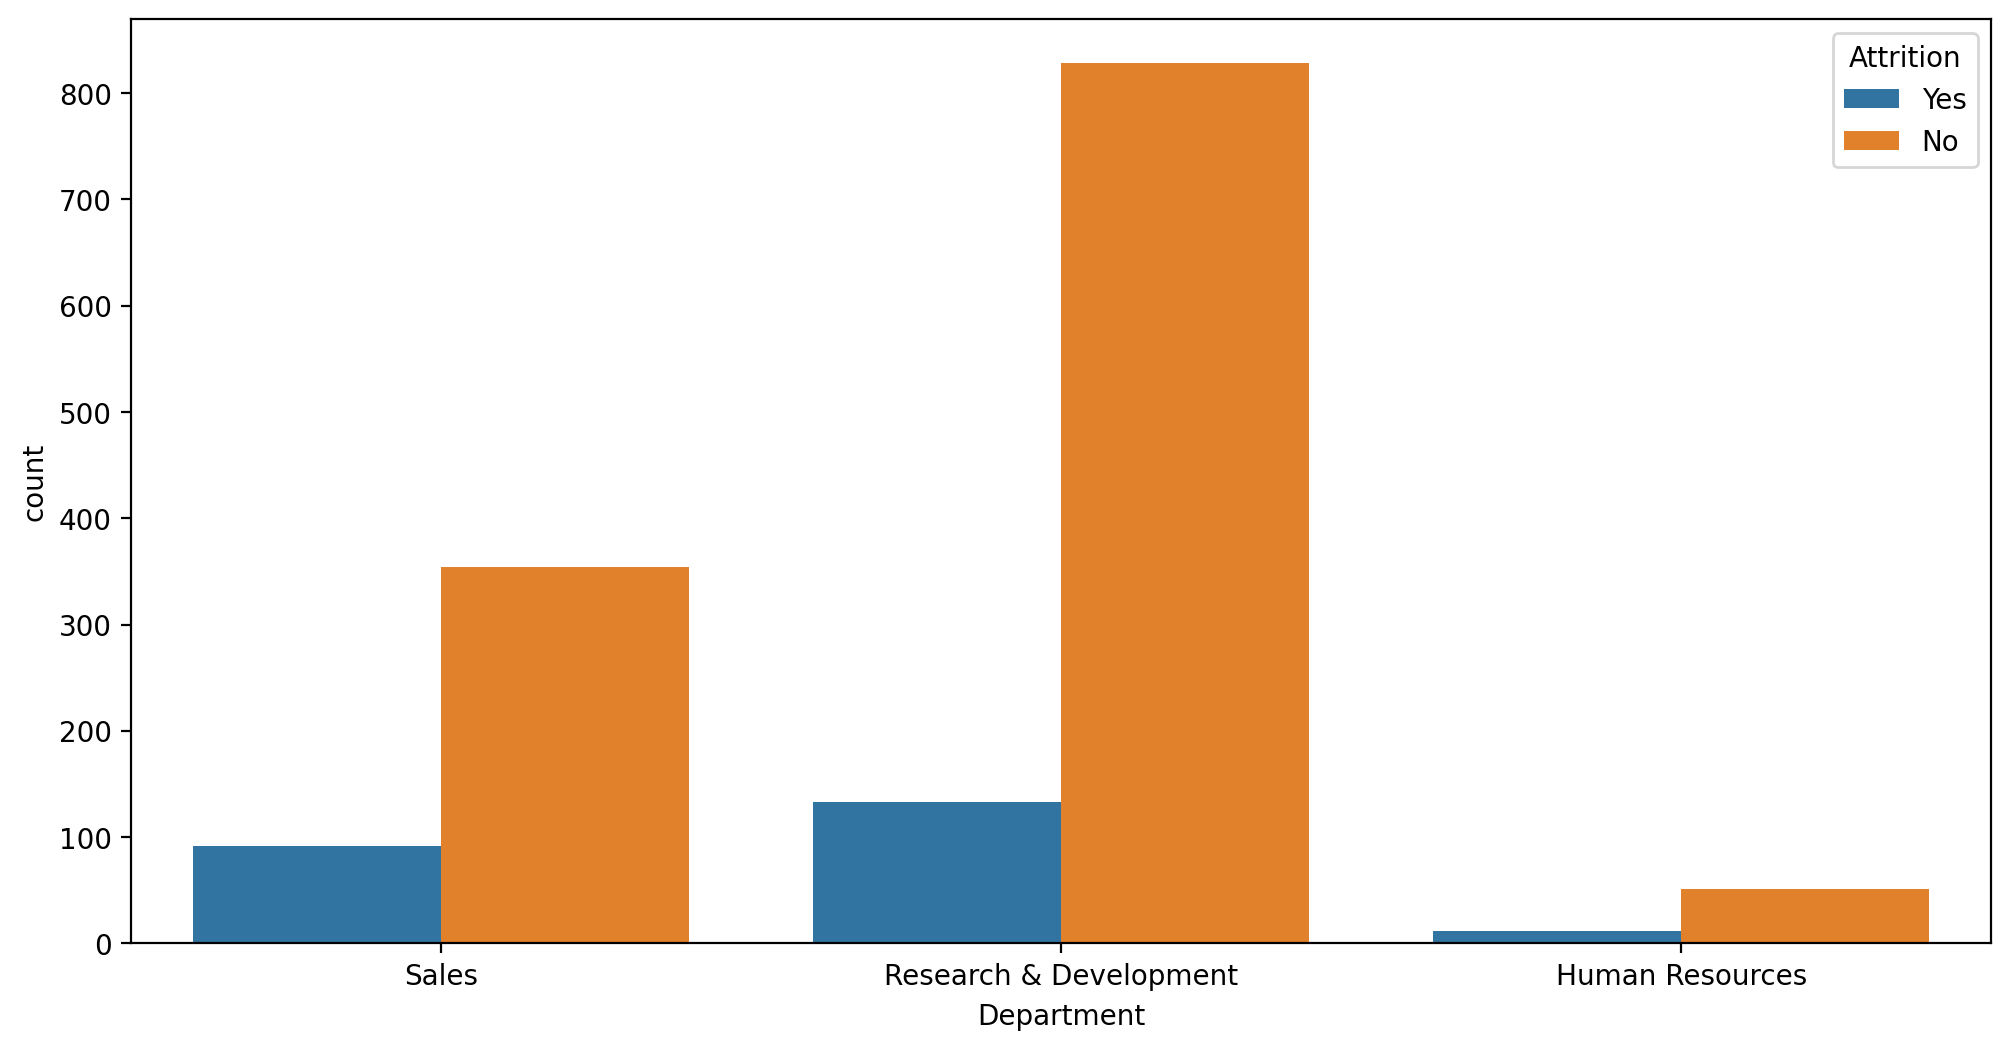

In [97]:
# Attrition vs Department
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='Department', hue='Attrition', data=data)

<Axes: xlabel='count', ylabel='JobRole'>

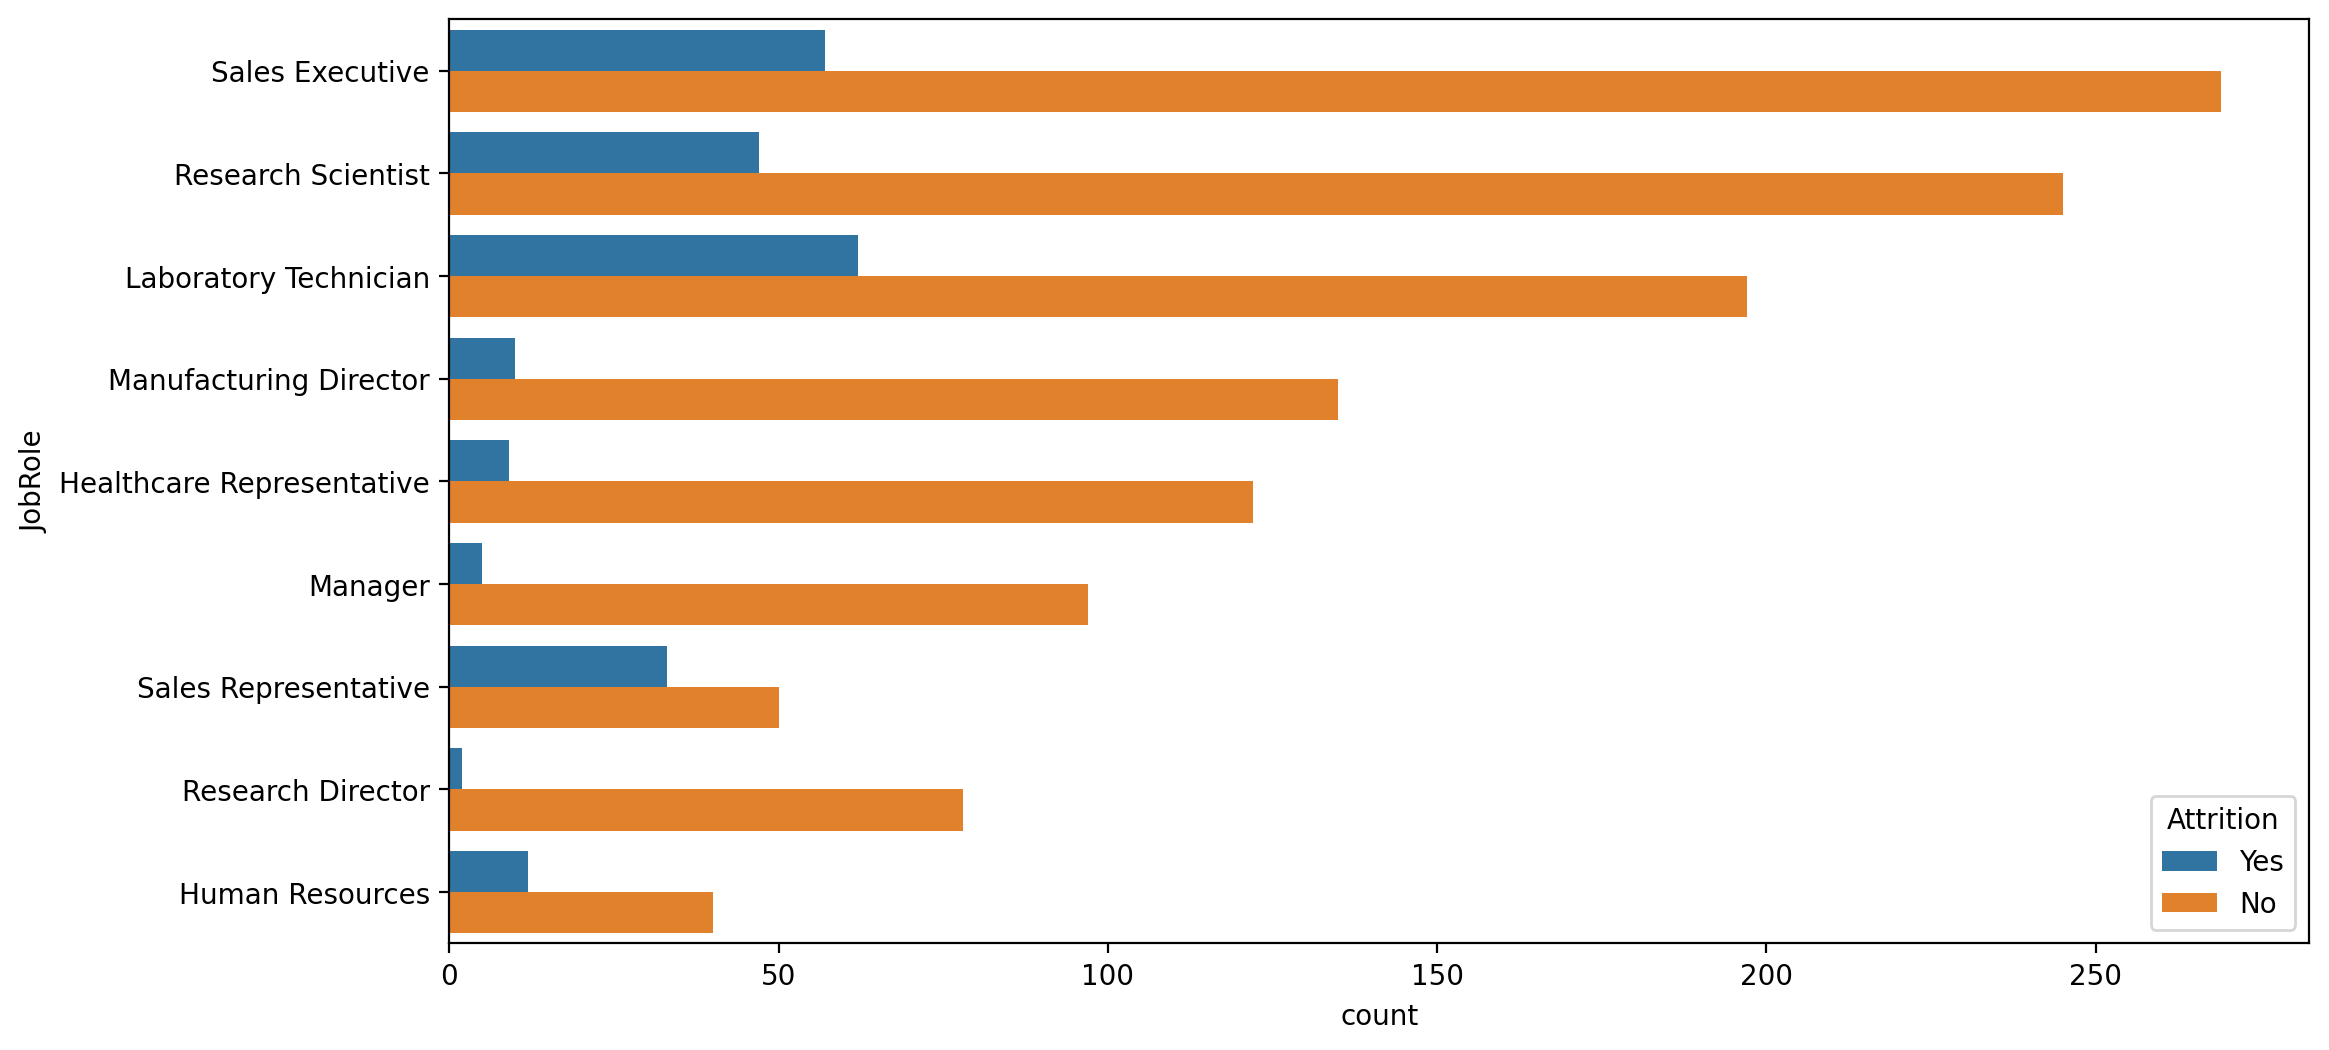

In [98]:
# Attrition vs JobRole
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(y='JobRole', hue='Attrition', data=data)

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

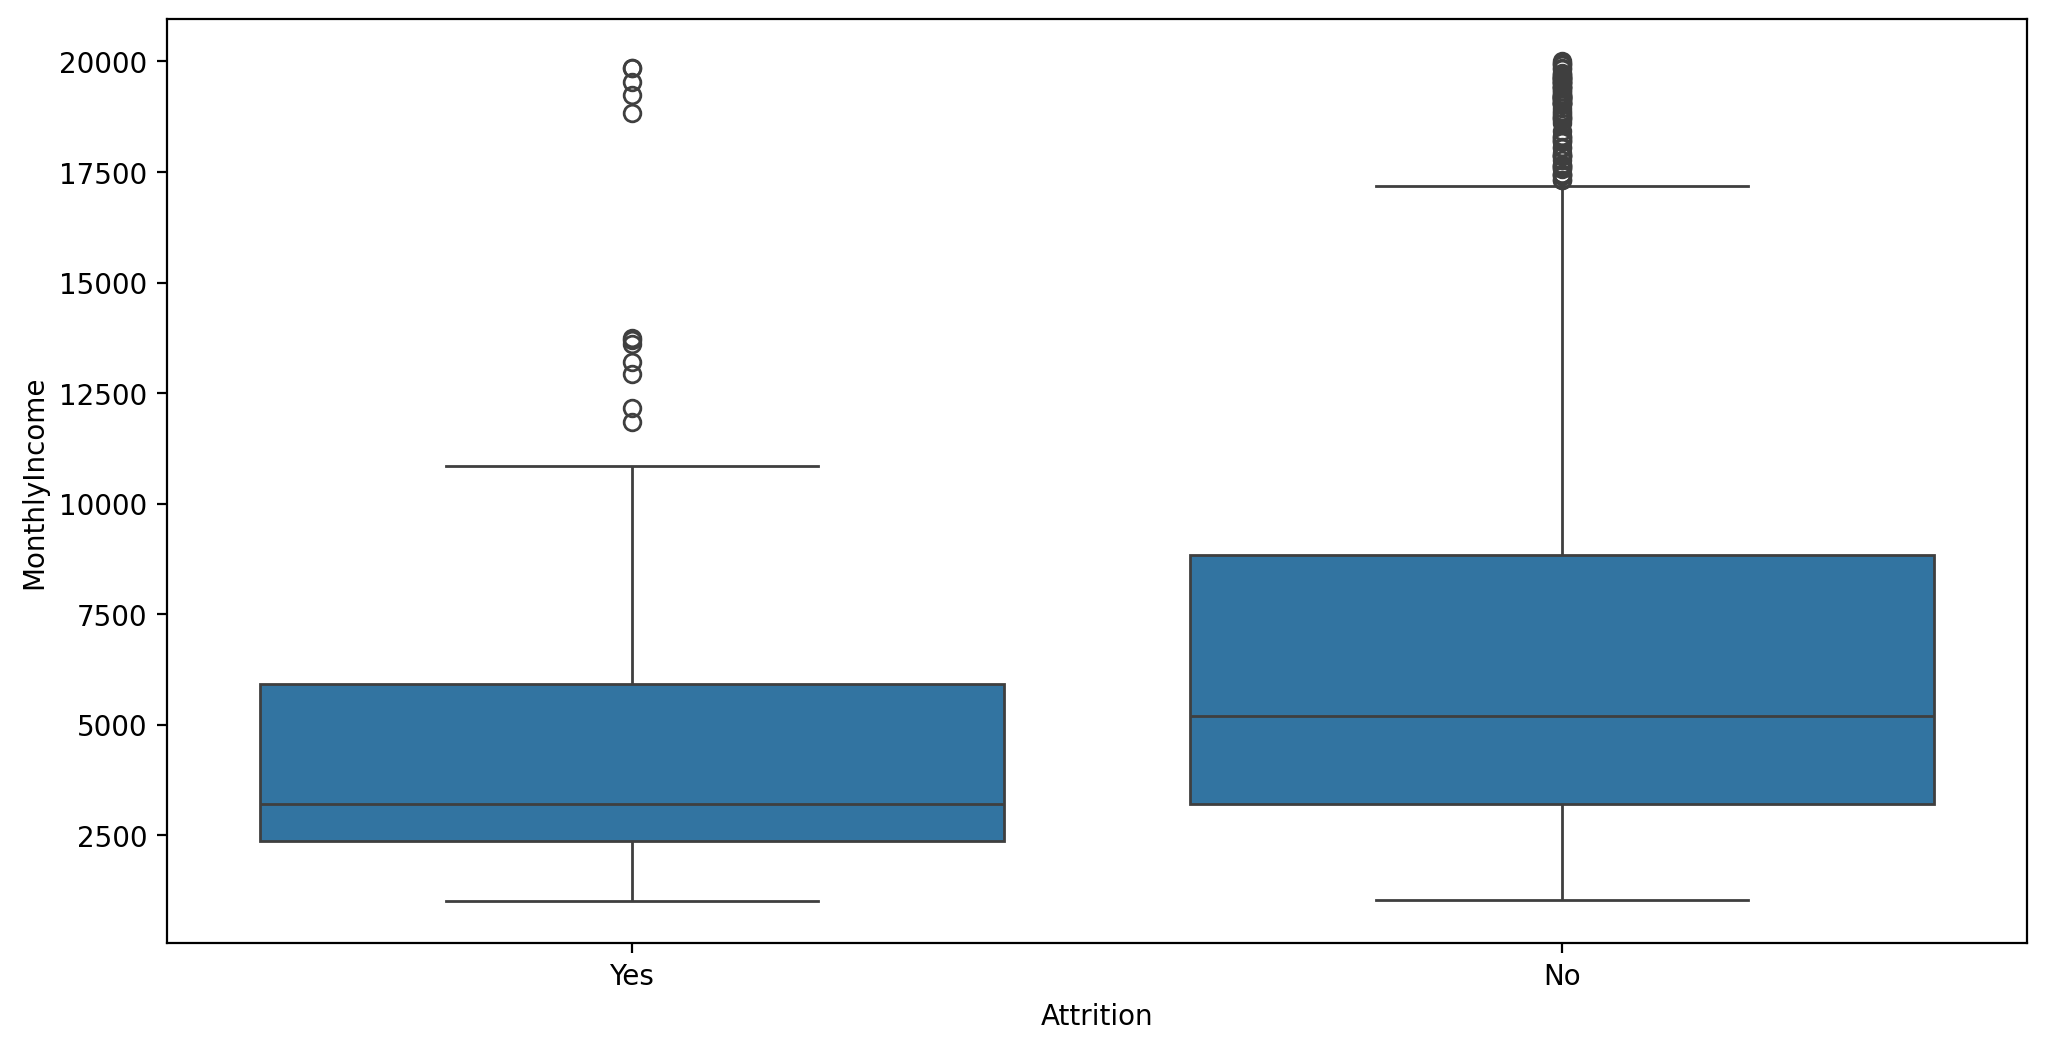

In [99]:
# Attrition vs Income
plt.figure(figsize=(12,6), dpi=200)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data)

<Axes: xlabel='Attrition', ylabel='Age'>

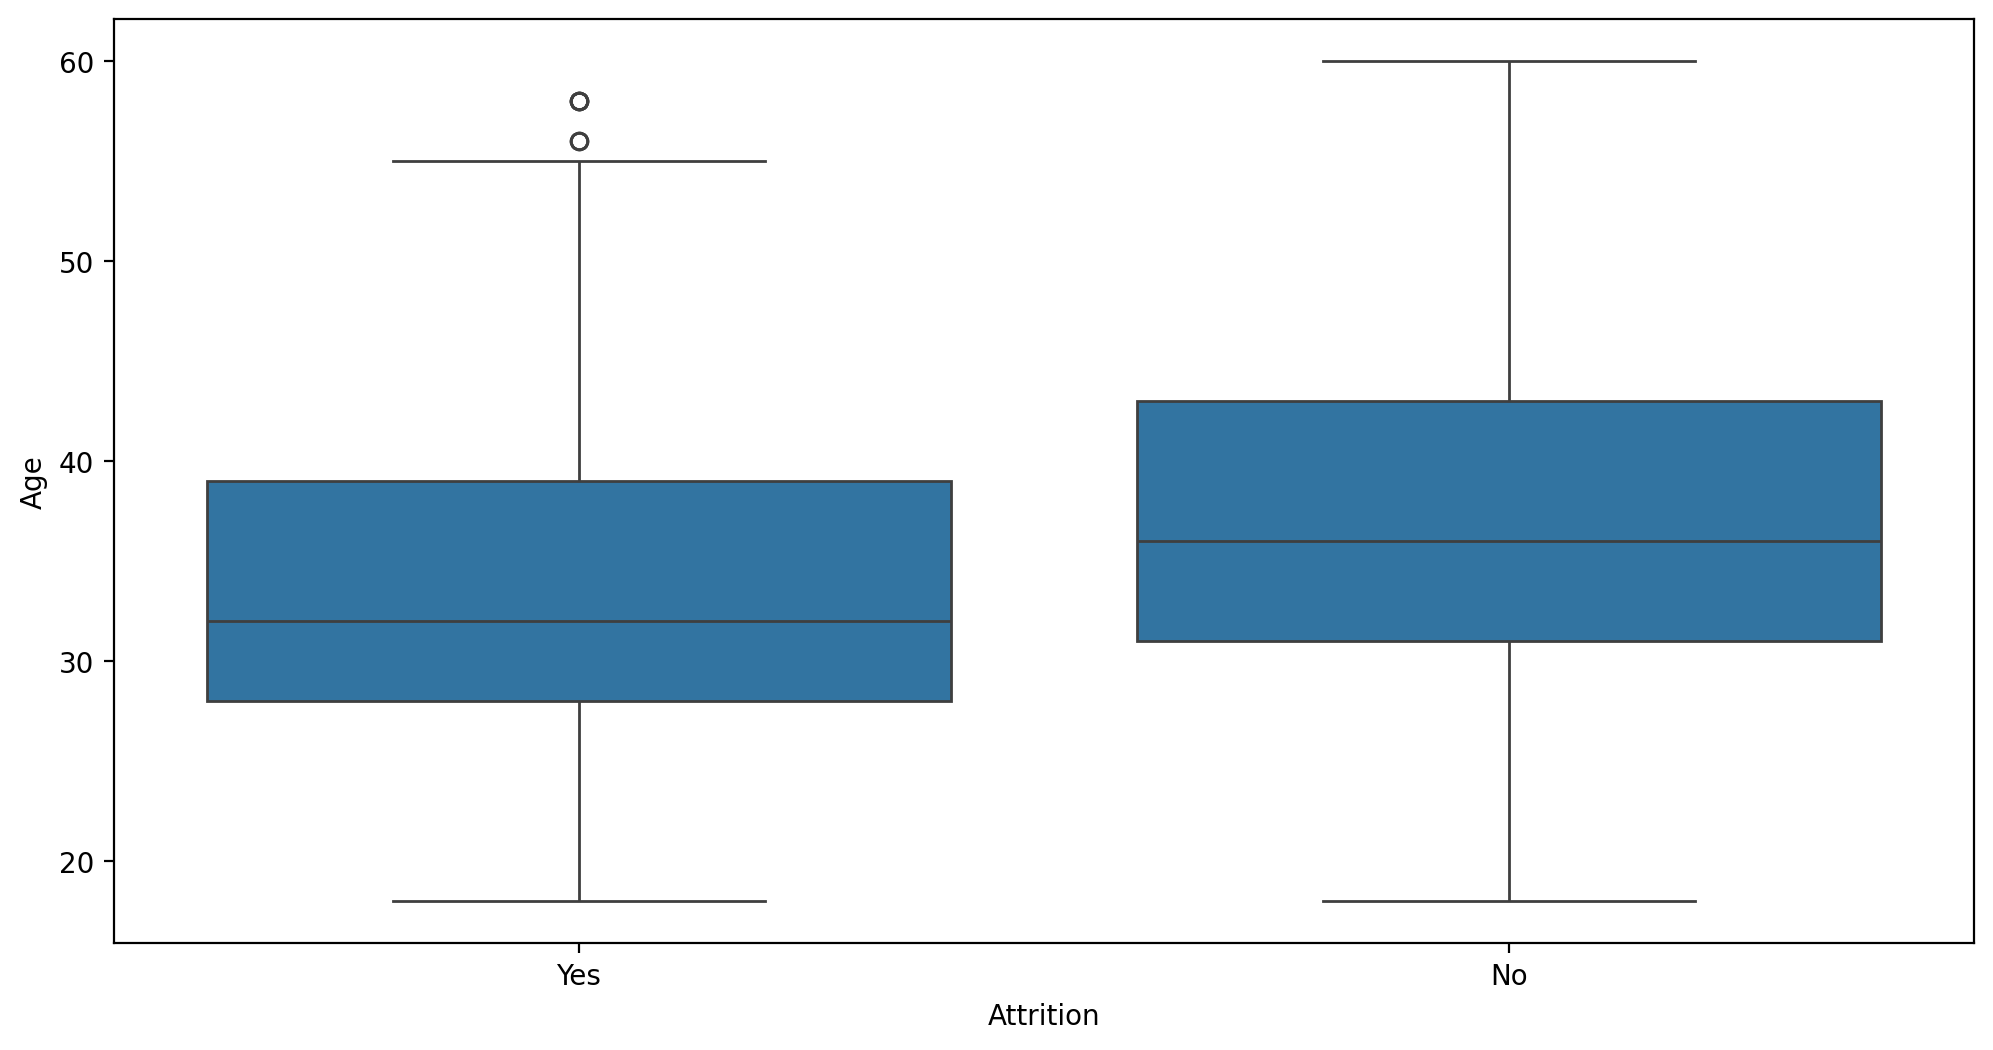

In [100]:
# Attrition vs Age
plt.figure(figsize=(12,6), dpi=200)
sns.boxplot(x='Attrition', y='Age', data=data)

<Axes: xlabel='JobSatisfaction', ylabel='count'>

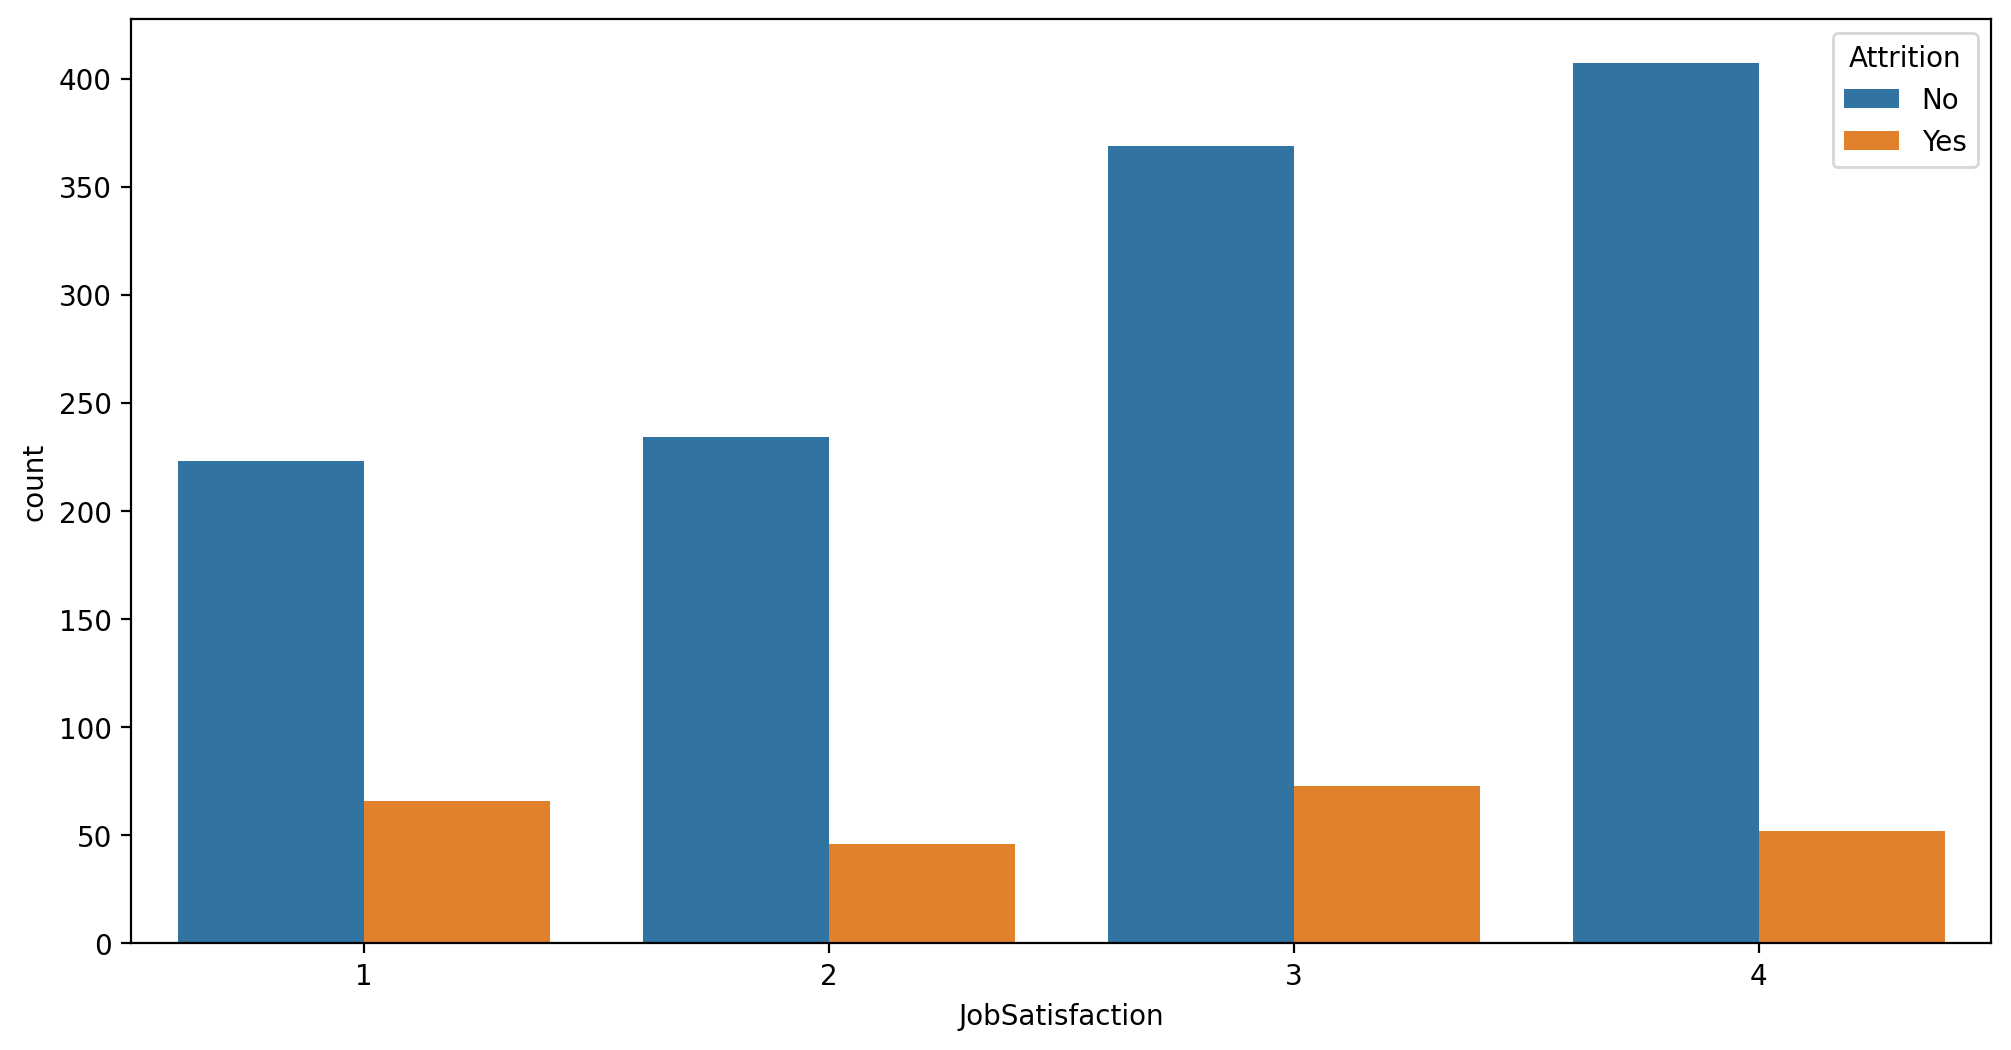

In [101]:
# Attrition vs Job Satisfaction
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='JobSatisfaction', hue='Attrition', data=data)

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

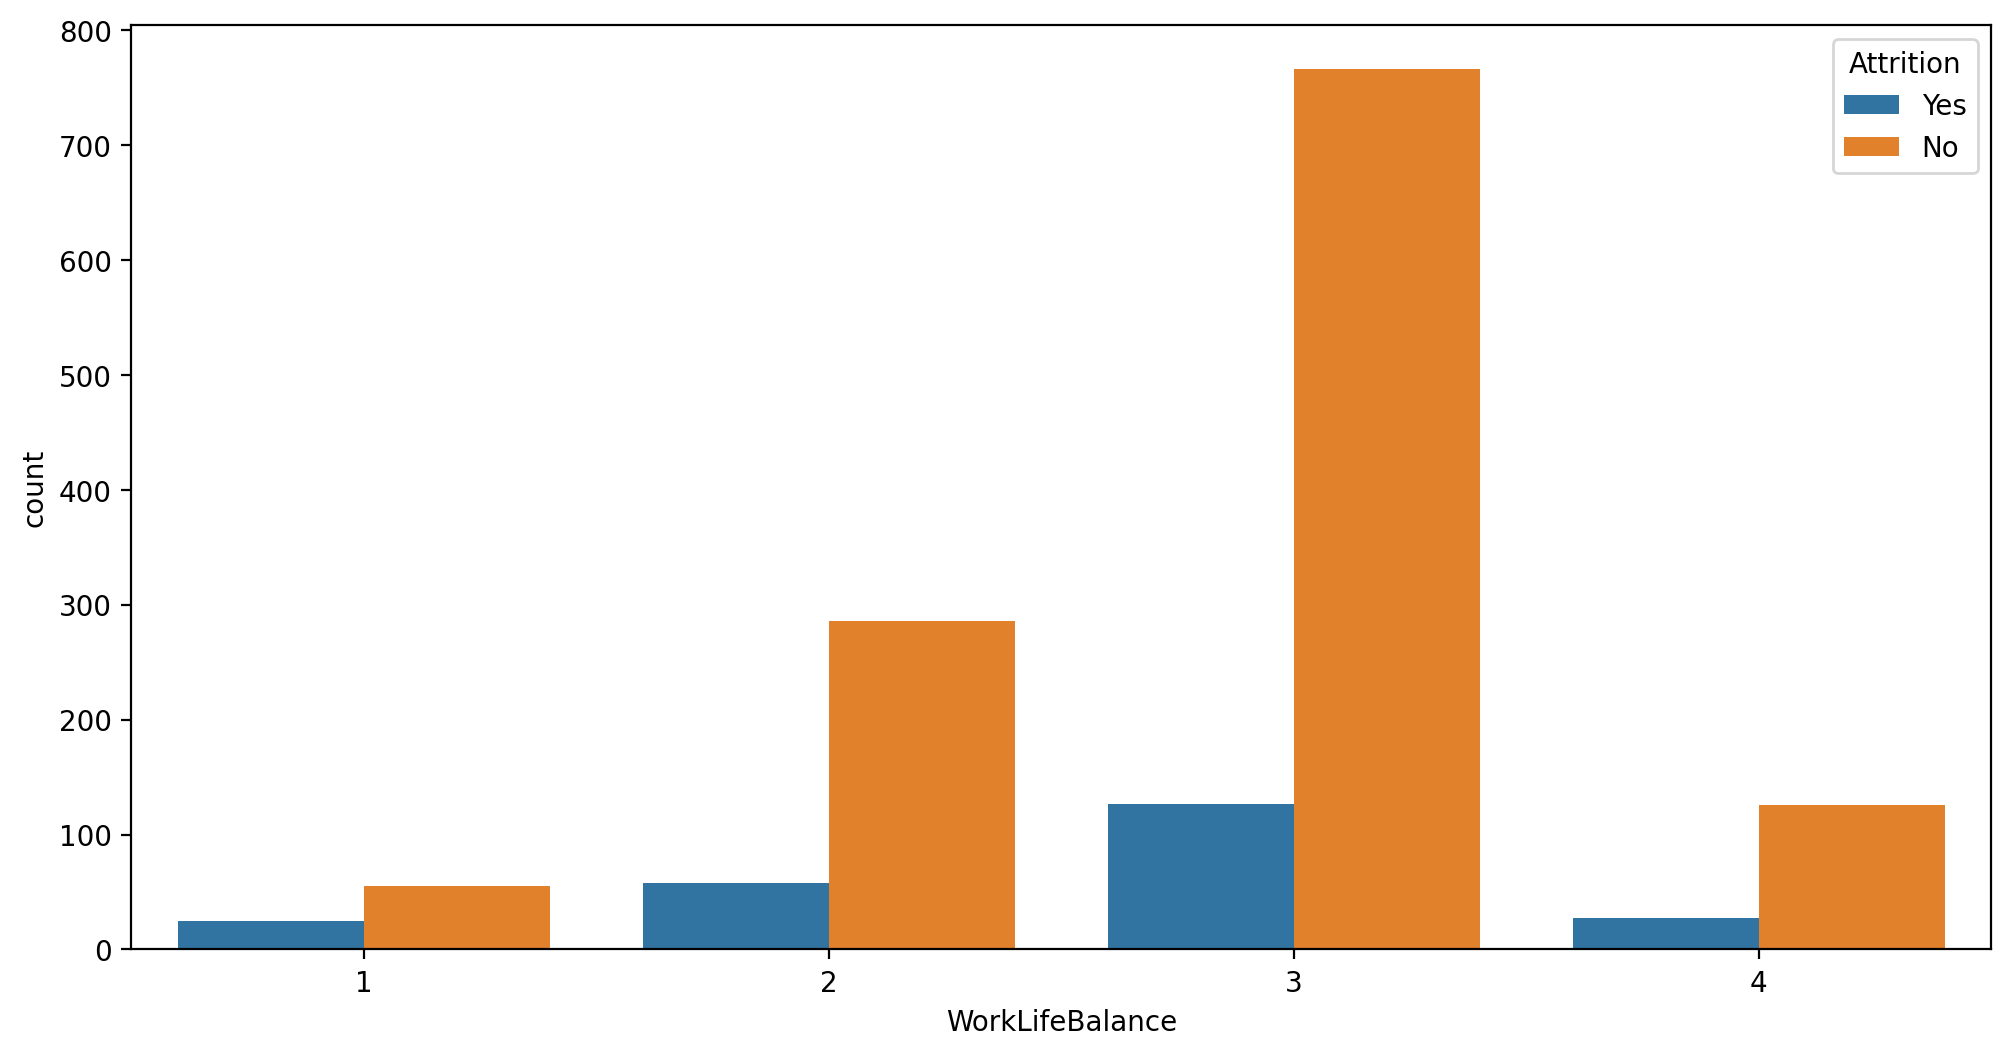

In [102]:
# Attrition vs Work-Life Balance
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=data)

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

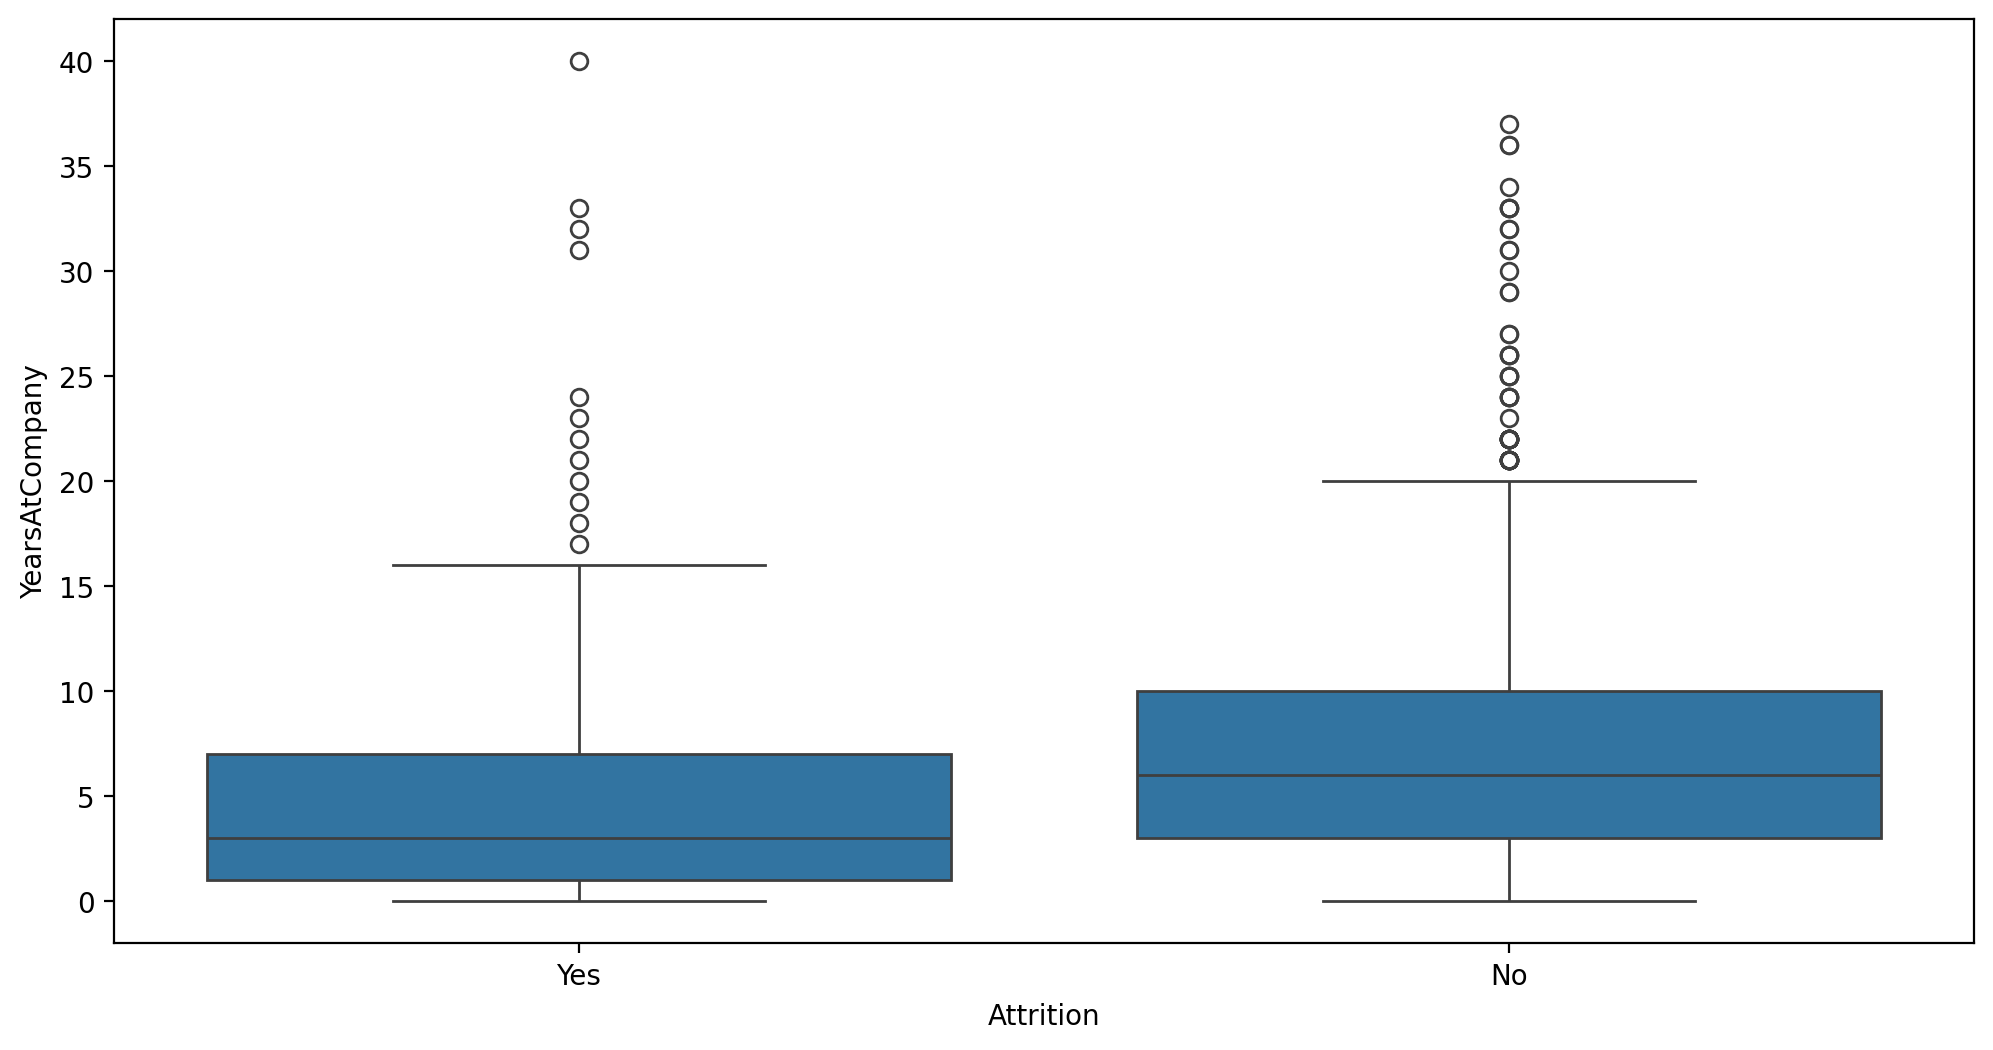

In [103]:
# Attrition vs YearsAtCompany
plt.figure(figsize=(12,6), dpi=200)
sns.boxplot(x='Attrition', y='YearsAtCompany', data=data)

<Axes: xlabel='BusinessTravel', ylabel='count'>

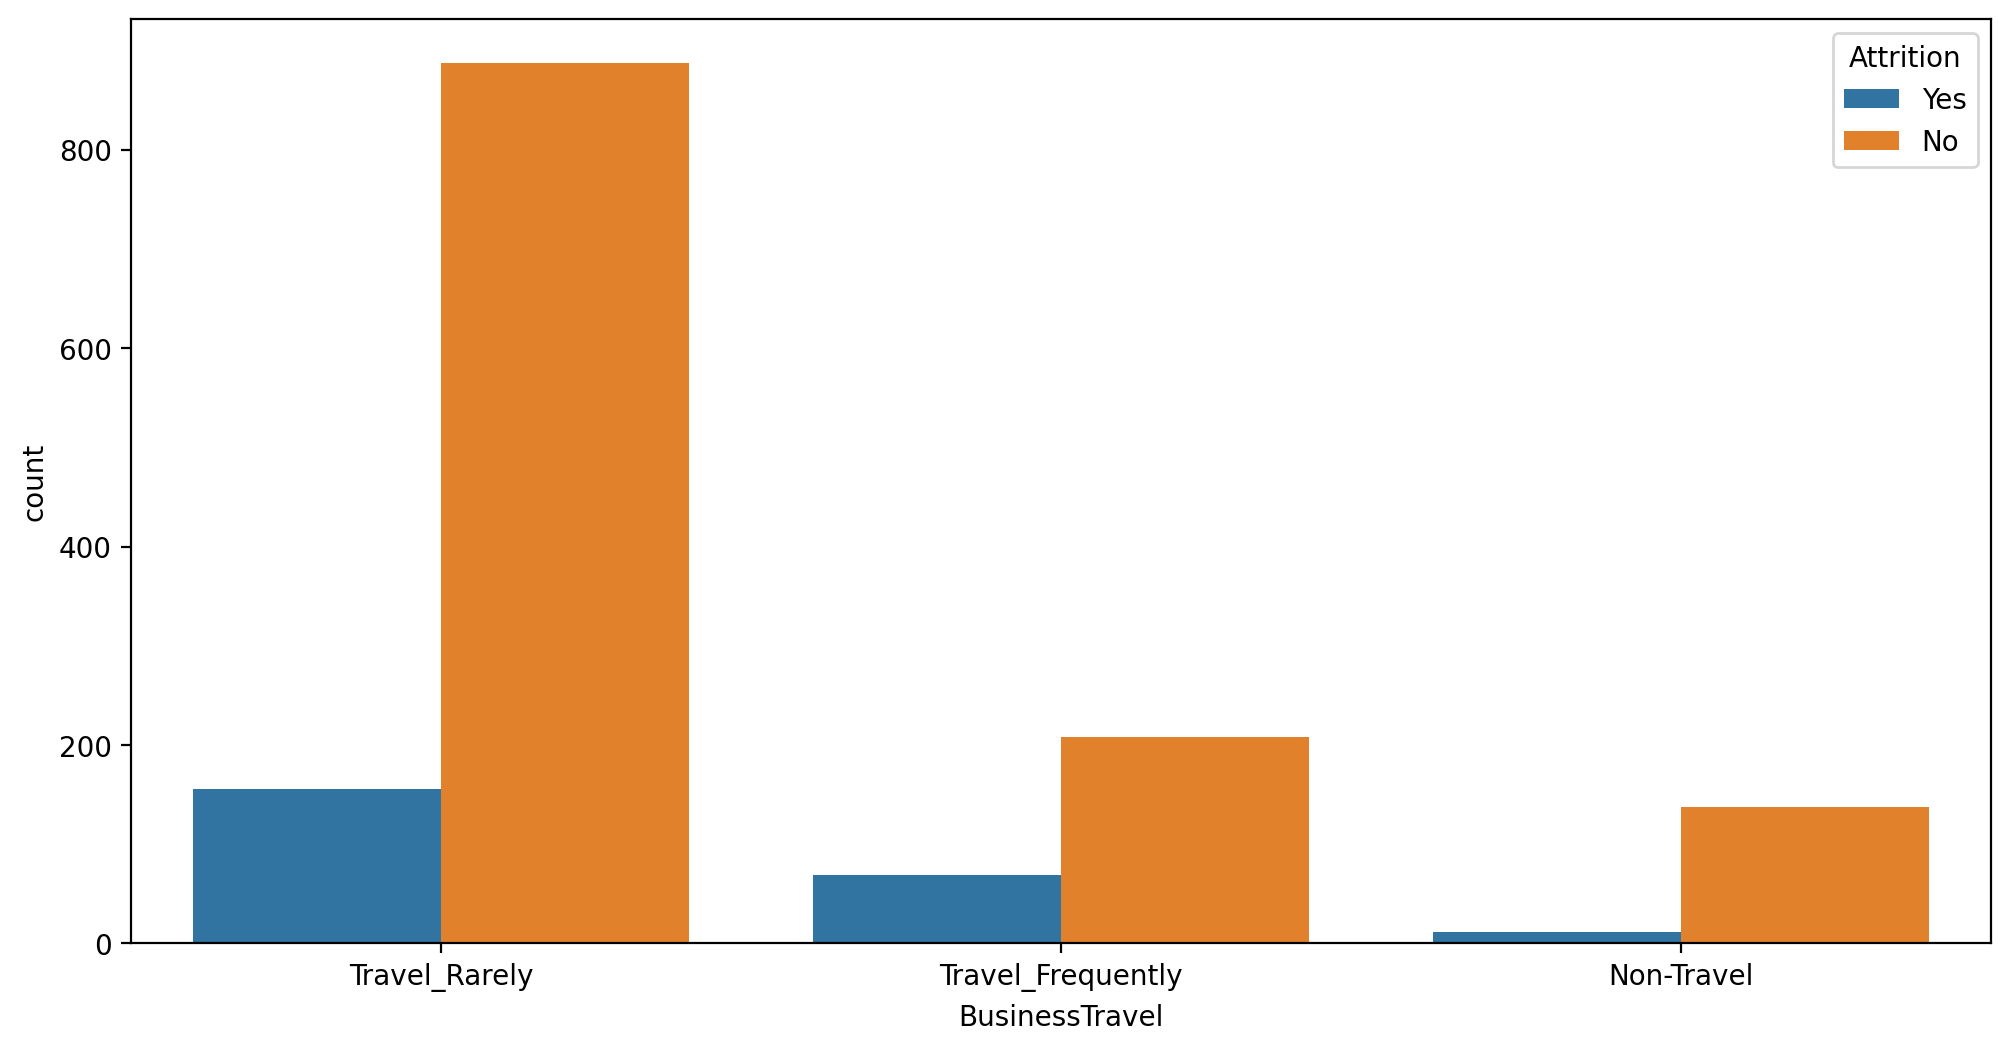

In [104]:
# Attrition vs Business Travel
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='BusinessTravel', hue='Attrition', data=data)

<Axes: xlabel='MaritalStatus', ylabel='count'>

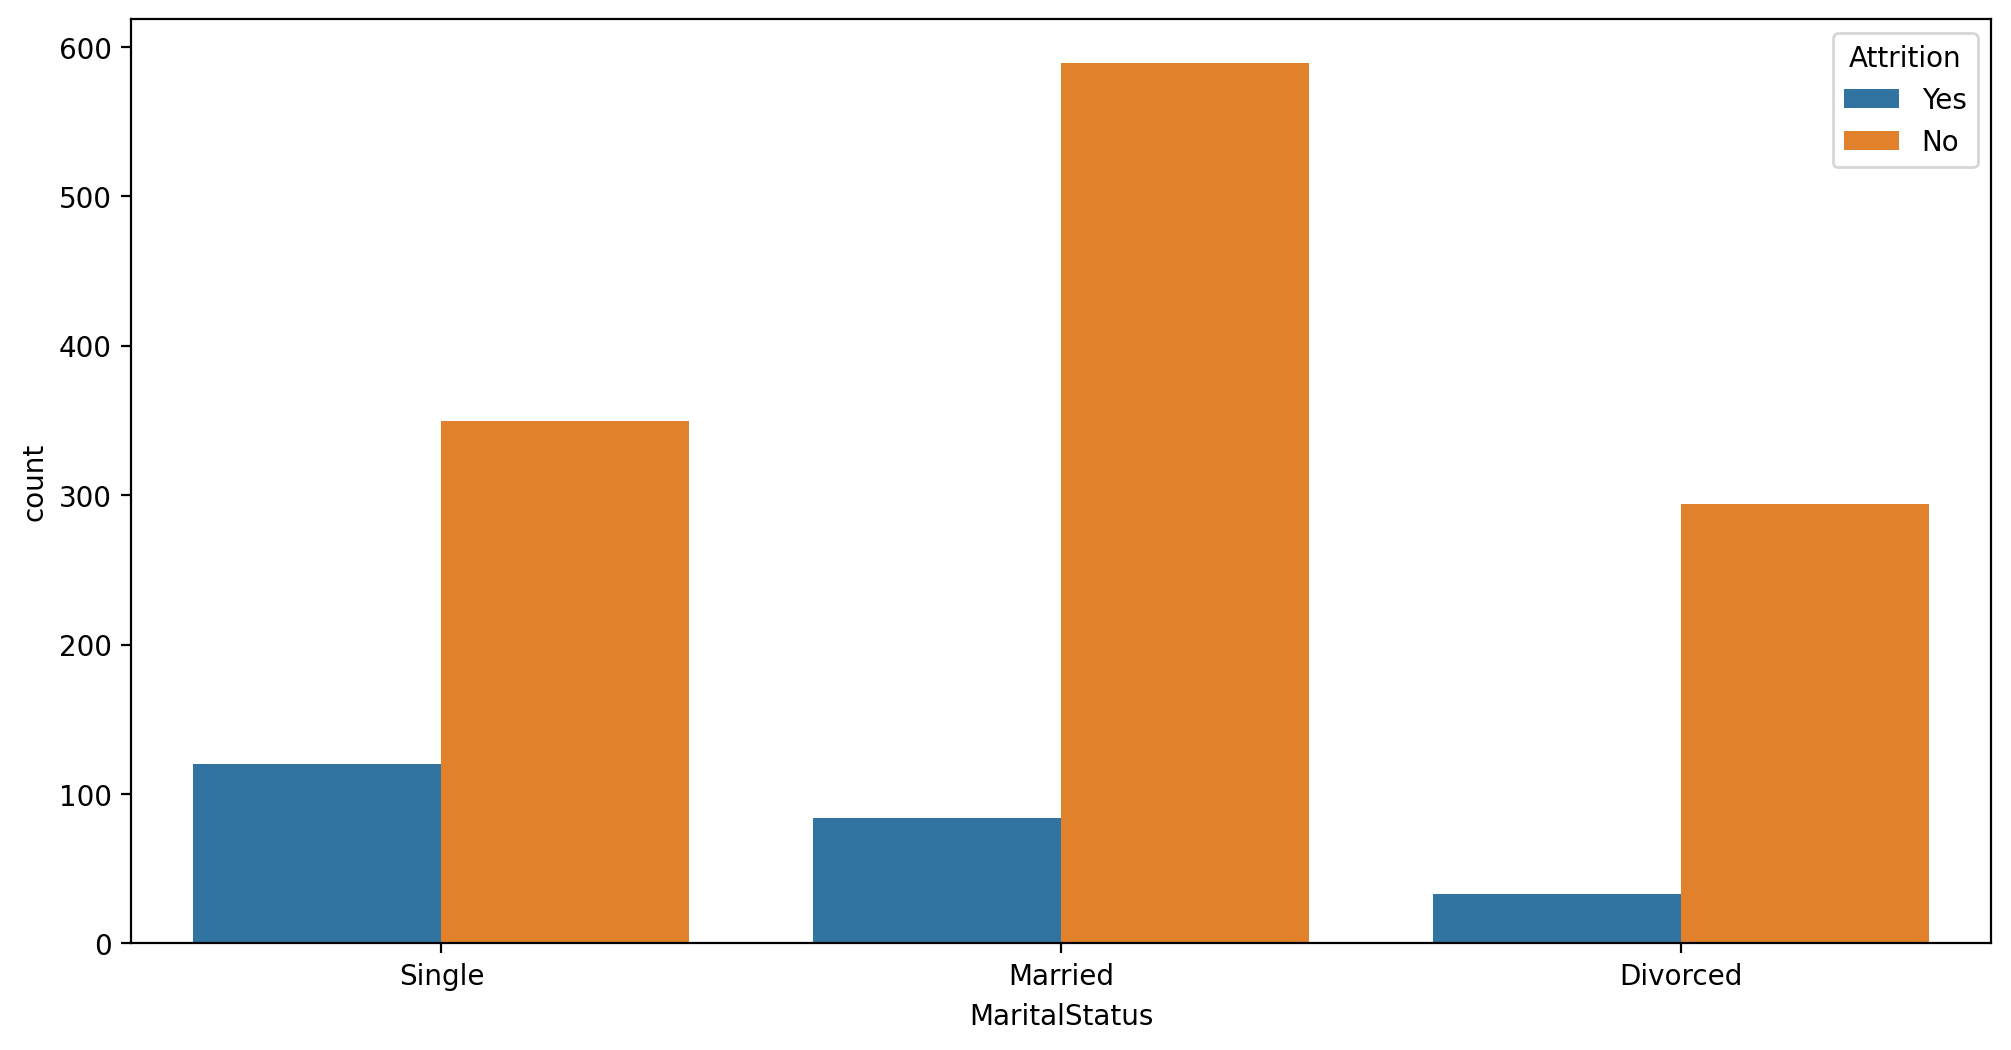

In [105]:
# Attrition vs Marital Status
plt.figure(figsize=(12,6), dpi=200)
sns.countplot(x='MaritalStatus', hue='Attrition', data=data)

<Axes: >

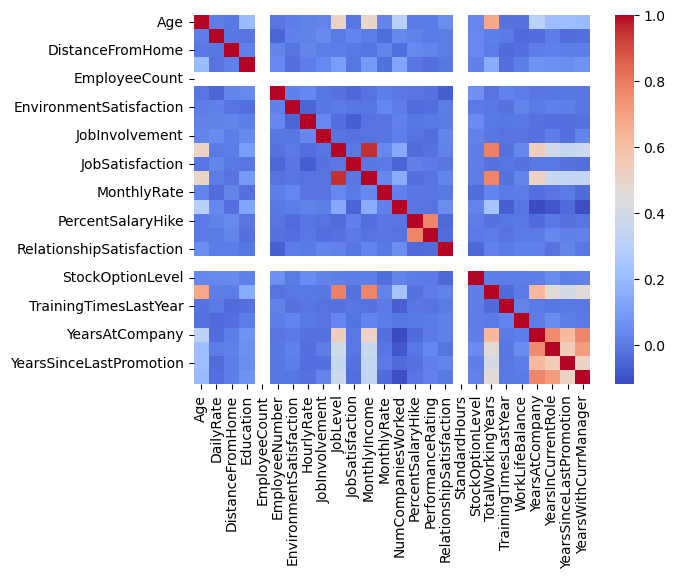

In [106]:
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')

In [107]:
X = data.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours','Attrition'], axis=1)
data['Attrition'] = data['Attrition'].str.strip()
data['Attrition'] = data['Attrition'].map({'Yes':1, 'No':0})
Y = data[['Attrition']]

In [108]:
print('Independent feature Set Shape : ', X.shape)
print('Dependent feature Set Shape   : ', Y.shape)

Independent feature Set Shape :  (1470, 30)
Dependent feature Set Shape   :  (1470, 1)


In [109]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2, stratify=Y)

In [110]:
cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'MaritalStatus', 'OverTime', 'JobRole']
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

#Fit on train set
encoder.fit(x_train[cols])

#Transform Train and Test Set
x_train[cols] = encoder.transform(x_train[cols])
x_test[cols] = encoder.transform(x_test[cols])

In [111]:
# Logistic Regression Model

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [112]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [113]:
pred_train1 = model1.predict(x_train_scaled)
pred_test1 = model1.predict(x_test_scaled)

In [114]:
print("Training Accuracy :", accuracy_score(y_train, pred_train1))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test1))

Training Accuracy : 0.8826530612244898
Testing Accuracy  : 0.8605442176870748


In [115]:
print("Training Recall :", recall_score(y_train, pred_train1))
print("Testing Recall  :", recall_score(y_test, pred_test1))

Training Recall : 0.37894736842105264
Testing Recall  : 0.40425531914893614


In [116]:
# Class Weights
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model2.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [117]:
pred_train2 = model2.predict(x_train_scaled)
pred_test2 = model2.predict(x_test_scaled)

In [118]:
print("Training Accuracy :", accuracy_score(y_train, pred_train2))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test2))

Training Accuracy : 0.766156462585034
Testing Accuracy  : 0.7346938775510204


In [119]:
print("Training Recall :", recall_score(y_train, pred_train2))
print("Testing Recall  :", recall_score(y_test, pred_test2))

Training Recall : 0.7789473684210526
Testing Recall  : 0.723404255319149


In [120]:
print(classification_report(y_test, pred_test1))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       247
           1       0.59      0.40      0.48        47

    accuracy                           0.86       294
   macro avg       0.74      0.68      0.70       294
weighted avg       0.85      0.86      0.85       294



In [121]:
print(classification_report(y_test, pred_test2))

              precision    recall  f1-score   support

           0       0.93      0.74      0.82       247
           1       0.34      0.72      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.73      0.64       294
weighted avg       0.84      0.73      0.77       294



In [122]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier()
search_params = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 10, 15, None],
    'max_features' : [5,10,15,20,25,30],
}
grid_search = GridSearchCV(estimator=model3,
                           param_grid=search_params,
                           scoring=['accuracy', 'precision', 'recall', 'f1'],
                           cv = 5,
                           refit = 'f1',
                           verbose=3)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.852) f1: (test=0.222) precision: (test=0.714) recall: (test=0.132) total time=   0.1s
[CV 2/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.855) f1: (test=0.227) precision: (test=0.833) recall: (test=0.132) total time=   0.1s
[CV 3/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.851) f1: (test=0.146) precision: (test=1.000) recall: (test=0.079) total time=   0.1s
[CV 4/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.872) f1: (test=0.375) precision: (test=0.900) recall: (test=0.237) total time=   0.1s
[CV 5/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.860) f1: (test=0.233) precision: (test=1.000) recall: (test=0.132) total time=   0.1s
[CV 1/5] END max_depth=5, max_features=5, n_estimators=200; accuracy: (test=0.847) f1: (test=0.182) precision: (test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [123]:
grid_search.best_params_

{'max_depth': 15, 'max_features': 25, 'n_estimators': 100}

In [124]:
best_model = grid_search.best_estimator_

pred_train3 = best_model.predict(x_train)
pred_test3 = best_model.predict(x_test)

In [125]:
print("Training Accuracy :", accuracy_score(y_train, pred_train3))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test3))

Training Accuracy : 1.0
Testing Accuracy  : 0.8503401360544217


In [126]:
print("Training Recall :", recall_score(y_train, pred_train3))
print("Testing Recall  :", recall_score(y_test, pred_test3))

Training Recall : 1.0
Testing Recall  : 0.2765957446808511


In [127]:
print(confusion_matrix(y_test, pred_test3))

[[237  10]
 [ 34  13]]


In [128]:
# Class weights

model4 = RandomForestClassifier(class_weight='balanced',random_state=42)
search_params = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 10, 15, None],
    'max_features' : [5,10,15,20,25,30],
}
grid_search = GridSearchCV(estimator=model4,
                           param_grid=search_params,
                           scoring=['accuracy', 'precision', 'recall', 'f1'],
                           cv = 5,
                           refit = 'f1',
                           verbose=3)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.886) f1: (test=0.630) precision: (test=0.657) recall: (test=0.605) total time=   0.1s
[CV 2/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.834) f1: (test=0.506) precision: (test=0.488) recall: (test=0.526) total time=   0.1s
[CV 3/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.813) f1: (test=0.371) precision: (test=0.406) recall: (test=0.342) total time=   0.1s
[CV 4/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.813) f1: (test=0.405) precision: (test=0.417) recall: (test=0.395) total time=   0.1s
[CV 5/5] END max_depth=5, max_features=5, n_estimators=100; accuracy: (test=0.881) f1: (test=0.533) precision: (test=0.727) recall: (test=0.421) total time=   0.1s
[CV 1/5] END max_depth=5, max_features=5, n_estimators=200; accuracy: (test=0.881) f1: (test=0.600) precision: (test=0

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [129]:
grid_search.best_params_

{'max_depth': 5, 'max_features': 10, 'n_estimators': 200}

In [130]:
best_model = grid_search.best_estimator_

pred_train4 = best_model.predict(x_train)
pred_test4 = best_model.predict(x_test)

In [131]:
print("Training Accuracy :", accuracy_score(y_train, pred_train4))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test4))

Training Accuracy : 0.9098639455782312
Testing Accuracy  : 0.8231292517006803


In [132]:
print("Training Recall :", recall_score(y_train, pred_train4))
print("Testing Recall  :", recall_score(y_test, pred_test4))

Training Recall : 0.7578947368421053
Testing Recall  : 0.48936170212765956


In [133]:
print(classification_report(y_test, pred_test4))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       247
           1       0.45      0.49      0.47        47

    accuracy                           0.82       294
   macro avg       0.68      0.69      0.68       294
weighted avg       0.83      0.82      0.83       294



In [134]:
from xgboost import XGBClassifier

model5 = XGBClassifier(
    scale_pos_weight=5.2,
    random_state=42
)

search_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
}

In [135]:
grid_search = GridSearchCV(
    estimator=model5,
    param_grid=search_params,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    refit='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [136]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [137]:
best_model = grid_search.best_estimator_

pred_train5 = best_model.predict(x_train)
pred_test5 = best_model.predict(x_test)

In [138]:
print("Training Accuracy :", accuracy_score(y_train, pred_train5))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test5))

Training Accuracy : 0.8979591836734694
Testing Accuracy  : 0.7959183673469388


In [139]:
print("Training Recall :", recall_score(y_train, pred_train5))
print("Testing Recall  :", recall_score(y_test, pred_test5))

Training Recall : 0.8736842105263158
Testing Recall  : 0.6170212765957447


In [140]:
print(classification_report(y_test, pred_test5))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       247
           1       0.41      0.62      0.49        47

    accuracy                           0.80       294
   macro avg       0.66      0.72      0.68       294
weighted avg       0.84      0.80      0.81       294



In [141]:
# Resampling

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [142]:
model6 = XGBClassifier(
    scale_pos_weight=5.2,
    random_state=42
)

search_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
}

In [143]:
grid_search = GridSearchCV(
    estimator=model6,
    param_grid=search_params,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    refit='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(x_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [144]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

In [145]:
best_model = grid_search.best_estimator_

pred_train6 = best_model.predict(x_train_smote)
pred_test6 = best_model.predict(x_test)

In [146]:
print("Training Accuracy :", accuracy_score(y_train_smote, pred_train6))
print("Testing Accuracy  :", accuracy_score(y_test, pred_test6))

Training Accuracy : 0.9969574036511156
Testing Accuracy  : 0.8469387755102041


In [147]:
print("Training Recall :", recall_score(y_train_smote, pred_train6))
print("Testing Recall  :", recall_score(y_test, pred_test6))

Training Recall : 1.0
Testing Recall  : 0.5106382978723404


In [148]:
print(classification_report(y_test, pred_test6))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       247
           1       0.52      0.51      0.52        47

    accuracy                           0.85       294
   macro avg       0.71      0.71      0.71       294
weighted avg       0.85      0.85      0.85       294



In [149]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7803428374536998


In [150]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                    Feature  Importance
18                 OverTime    0.166212
22         StockOptionLevel    0.087799
11                 JobLevel    0.079363
3                Department    0.050190
10           JobInvolvement    0.048375
1            BusinessTravel    0.047202
27       YearsInCurrentRole    0.040982
14            MaritalStatus    0.038484
7   EnvironmentSatisfaction    0.037760
20        PerformanceRating    0.033770
13          JobSatisfaction    0.033632
23        TotalWorkingYears    0.030436
25          WorkLifeBalance    0.030035
0                       Age    0.023338
15            MonthlyIncome    0.021796


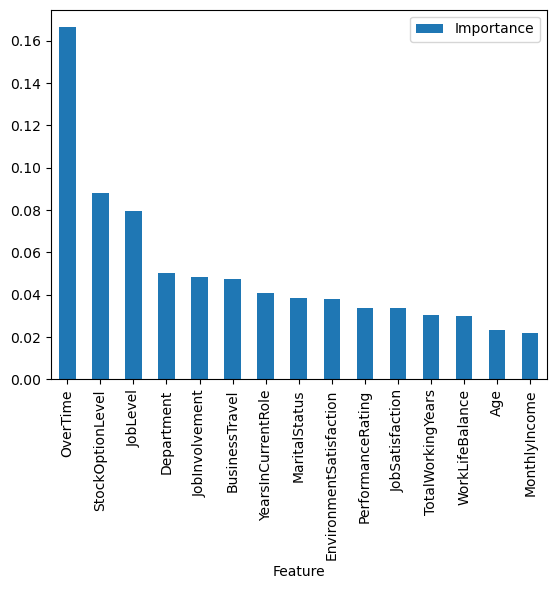

In [151]:
importance.head(15).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.show()

Conclusions


1. Overtime was the strongest predictor of attrition.

The XGBoost model identified OverTime as the most important feature. Employees working overtime were more likely to leave the organization, indicating that workload and work-life balance play a significant role in employee retention.


2. Stock Option Level significantly influenced retention.

Employees with different stock option levels showed varying attrition patterns. This suggests that financial incentives and long-term benefits can affect an employee's decision to stay with the company.

3. Job Level was an important factor.

The importance of JobLevel indicates that seniority and career progression impact employee turnover. Employees at different organizational levels may have different retention behaviors.

4. Department and Business Travel contributed to attrition.

The model found that Department and BusinessTravel influenced attrition predictions. This suggests that work environment, job responsibilities, and travel requirements may affect employee satisfaction and retention.

5. Employee Engagement Factors were important.

Features such as:

JobInvolvement
EnvironmentSatisfaction

were among the top predictors. This indicates that employee engagement and workplace satisfaction are strongly related to attrition risk.

In [154]:
X_reduced = data[['OverTime','StockOptionLevel', 'JobLevel', 'Department', 'JobInvolvement', 'BusinessTravel', 'YearsInCurrentRole',
              'MaritalStatus', 'EnvironmentSatisfaction', 'PerformanceRating', 'JobSatisfaction', 'TotalWorkingYears', 'WorkLifeBalance',
              'Age', 'MonthlyIncome']]

In [155]:
from sklearn.model_selection import train_test_split
x_train2, x_test2, y_train2, y_test2 = train_test_split(X_reduced, Y, test_size=0.2, random_state=2, stratify=Y)

In [157]:
cols = ['BusinessTravel', 'Department', 'MaritalStatus', 'OverTime']
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

#Fit on train set
encoder.fit(x_train2[cols])

#Transform Train and Test Set
x_train2[cols] = encoder.transform(x_train2[cols])
x_test2[cols] = encoder.transform(x_test2[cols])

In [158]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote2, y_train_smote2 = smote.fit_resample(
    x_train2,
    y_train2
)

In [159]:
model7 = XGBClassifier(
    scale_pos_weight=5.2,
    random_state=42
)

search_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
}

In [160]:
grid_search = GridSearchCV(
    estimator=model7,
    param_grid=search_params,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    refit='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(x_train_smote2, y_train_smote2)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [162]:
best_model2 = grid_search.best_estimator_

pred_train7 = best_model2.predict(x_train_smote2)
pred_test7 = best_model2.predict(x_test2)

In [163]:
print("Training Accuracy :", accuracy_score(y_train_smote2, pred_train7))
print("Testing Accuracy  :", accuracy_score(y_test2, pred_test7))

Training Accuracy : 0.9756592292089249
Testing Accuracy  : 0.7959183673469388


In [164]:
print("Training Recall :", recall_score(y_train_smote2, pred_train7))
print("Testing Recall  :", recall_score(y_test2, pred_test7))

Training Recall : 1.0
Testing Recall  : 0.5319148936170213


In [165]:
print(classification_report(y_test2, pred_test7))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87       247
           1       0.40      0.53      0.45        47

    accuracy                           0.80       294
   macro avg       0.65      0.69      0.66       294
weighted avg       0.82      0.80      0.81       294



In [166]:
joblib.dump(best_model2, 'best_model2.pkl')
print("Model Saved")

Model Saved


### Deployment-Oriented Feature Selection

The initial XGBoost model was trained using all available features and achieved the best performance with an F1-score of 0.52 and a ROC-AUC score of 0.78.

However, deploying a model that requires users to manually enter all features would result in a complex and less user-friendly application. To improve usability, a reduced feature set was created using the most important predictors identified through feature importance analysis.

The selected features were:

* OverTime
* StockOptionLevel
* JobLevel
* Department
* JobInvolvement
* BusinessTravel
* YearsInCurrentRole
* MaritalStatus
* EnvironmentSatisfaction
* PerformanceRating
* JobSatisfaction
* TotalWorkingYears
* WorkLifeBalance
* Age
* MonthlyIncome

A new model was trained using these 15 features. Although the reduced model showed slightly lower performance compared to the full-feature model, it significantly improved practicality for deployment by reducing the number of required inputs while maintaining reasonable predictive capability.

This trade-off between model performance and usability makes the reduced-feature model more suitable for a real-world web application, while the full-feature model remains the best-performing analytical model.


In [167]:
for col, categories in zip(
    ['BusinessTravel','Department','MaritalStatus','OverTime'],
    encoder.categories_
):
    print(f"\n{col}")
    for i, category in enumerate(categories):
        print(f"{category} -> {i}")


BusinessTravel
Non-Travel -> 0
Travel_Frequently -> 1
Travel_Rarely -> 2

Department
Human Resources -> 0
Research & Development -> 1
Sales -> 2

MaritalStatus
Divorced -> 0
Married -> 1
Single -> 2

OverTime
No -> 0
Yes -> 1
